# Polyhedral Relaxations for Factorable Functions

Given the image set $\Gamma:\{{\bf g}({\bf x}) \,\mid\, {\bf x}\in{\bf X}\subset\mathbb{R}^n\} \subseteq \mathbb R^m$ of a (potentially nonconvex) function ${\bf g}:\mathbb{R}^n\to\mathbb R^m$, a polyedral enclosure is any set $\overline\Gamma$ such that:
\begin{align*}
\overline{\Gamma} \coloneqq \left\{ {\bf G} {\bf v}\; \middle|\; \begin{array}{l} {\bf A} {\bf v} \;=\; {\bf 0}\\ {\bf B} {\bf v} \;\leq\; {\bf 0}\\ {\bf v}^{\rm L}\leq{\bf v}\leq{\bf v}^{\rm U} \end{array} \right\} \supseteq \Gamma\, ,
\end{align*}
where the variable vector ${\bf v}$ contains the original variable vector ${\bf x}$, and ${\bf G}$ is a projection matrix onto the $m$-dimensional image subspace.

The modules `PolImg`, `PolVar` and `PolCut` in PyMC provide a means of constructing the linear cuts ${\bf A} {\bf v} = {\bf 0}$ and ${\bf B} {\bf v} \leq {\bf 0}$ in such polyhedral enclosure for a multivariate factorable functions over an interval domains $\mathbf{X}\coloneqq [{\bf x}^{\rm L},{\bf x}^{\rm U}]\in\mathbb{IR}^n$. They build upon the DAG modules `FFGraph`, `FFVar` and `FFOp` (cf. [Other notebook](./ffunc.ipynb)).

## Computing a Polyhedral Image for a Factorable Function in PyMC

Suppose we want to compute a polyhedral relaxation of the factorable function $f(x,y)=x(\exp(x)-y)^2$ for $(x,y)\in [-2,1]\times[-1,2]$. 

We start by importing the PyMC library:

In [1]:
import pymc

An environment `FFGraph` is first defined for recording the DAG of the function:

In [2]:
DAG = pymc.FFGraph()

X = DAG.add_var( "X" )
Y = DAG.add_var( "Y" )
F = X*(pymc.exp(X)-Y)**2
print( F.str() )

X * SQR( EXP( X ) - Y )


Next, we proceed by defining an polyhedral image with two independent variables, corresponding to the DAG variables `X[0]` an `X[1]`:

In [3]:
IMG = pymc.PolImg()
#IMG.options.ALLOW_QUAD = True
#IMG.options.ALLOW_NLIN = { pymc.FFOp.TYPE.EXP }
IMG.reset_cuts()

XI, YI = pymc.Interval(-2,1), pymc.Interval(-1,2)
XP, YP = pymc.PolVar( IMG, X, XI, True ), pymc.PolVar( IMG, Y, YI, True )
print( IMG )


VARIABLES:
  X	 in [ -2.00000e+00 :  1.00000e+00 ]	 (DAG: X)
  Y	 in [ -1.00000e+00 :  2.00000e+00 ]	 (DAG: Y)

NO AUXILIARY

NO CUT



We first evaluate the DAG of the factorable function to forward propagate the polyhedral image:

In [4]:
[FP] = DAG.eval( [F], [X,Y], [XP,YP] )
print( IMG )


VARIABLES:
  X	 in [ -2.00000e+00 :  1.00000e+00 ]	 (DAG: X)
  Y	 in [ -1.00000e+00 :  2.00000e+00 ]	 (DAG: Y)
  V2	 in [  1.35335e-01 :  2.71828e+00 ]	 (DAG: Z0)
  V3	 in [ -1.86466e+00 :  3.71828e+00 ]	 (DAG: Z1)
  V4	 in [  0.00000e+00 :  1.38256e+01 ]	 (DAG: Z2)
  V5	 in [ -2.76512e+01 :  1.38256e+01 ]	 (DAG: Z3)

NO AUXILIARY

NO CUT



Notice that intermediate variables `V2`, ..., `V5`have been appended to the polyhedral image, which correspond to the DAG intermediates `Z0`, ..., `Z3'.

Finally, we generate the polyhedral cuts through backward propagation:

In [5]:
IMG.generate_cuts( [FP] )
print( IMG )


VARIABLES:
  X	 in [ -2.00000e+00 :  1.00000e+00 ]	 (DAG: X)
  Y	 in [ -1.00000e+00 :  2.00000e+00 ]	 (DAG: Y)
  V2	 in [  1.35335e-01 :  2.71828e+00 ]	 (DAG: Z0)
  V3	 in [ -1.86466e+00 :  3.71828e+00 ]	 (DAG: Z1)
  V4	 in [  0.00000e+00 :  1.38256e+01 ]	 (DAG: Z2)
  V5	 in [ -2.76512e+01 :  1.38256e+01 ]	 (DAG: Z3)

NO AUXILIARY

CUTS:
  + 1.00000e+00V3 - 1.00000e+00V2 + 1.00000e+00Y = 0.00000e+00
  + 1.00000e+00V5 + 0.00000e+00X - 1.00000e+00V4 <= -0.00000e+00
  + 1.00000e+00V5 - 1.38256e+01X + 2.00000e+00V4 <= 2.76512e+01
  + 5.58295e+00V4 - 1.03486e+01V3 <= 3.87085e+01
  + 3.00000e+00V2 - 2.58295e+00X <= 5.57190e+00
  + 1.00000e+00V5 - 1.38256e+01X - 1.00000e+00V4 >= -1.38256e+01
  + 1.00000e+00V5 + 0.00000e+00X + 2.00000e+00V4 >= 0.00000e+00
  + 1.00000e+00V4 + 3.72933e+00V3 >= -3.47697e+00
  + 1.00000e+00V4 - 7.43656e+00V3 >= -1.38256e+01
  + 1.00000e+00V4 - 1.85362e+00V3 >= -8.58974e-01
  + 1.00000e+00V4 + 9.37856e-01V3 >= -2.19894e-01
  + 1.00000e+00V4 - 4.64509e+00V3 >= -5.3

Next, we show how to embed the cuts in a Gurobi optimization model.

In [6]:
import gurobipy as gp
from gurobipy import GRB

In [7]:
def create_model_from_polimage( img ):

    m = gp.Model("polimage")

    # Create variables
    GRBX = {}
    for var in img.vars.values():
        #print( var )
        GRBX[var.id] = m.addVar( lb=var.rng.l, ub=var.rng.u, name=var.name )
        if var.cnt == False:
            GRBX[var.id].VType = GRB.INTEGER
    #m.update()
    #print( GRBX )

    # Create constraints from cuts
    for cut in img.cuts:
        #print( cut )
        match cut.type:
            case pymc.PolCut.TYPE.EQ:
                #print( "equality" )
                ctr = 0.
                for a, x in zip( cut.coef, cut.var ):
                    ctr += a * GRBX[x.id]
                for a, x, y in zip( cut.qcoef, cut.qvar1, cut.qvar2 ):
                    if( x.id == y.id ):
                        ctr += a * GRBX[x.id]**2
                    else:
                        ctr += a * GRBX[x.id] * GRBX[y.id]
                m.addConstr( ctr == cut.rhs )
            case pymc.PolCut.TYPE.LE:
                #print( "<= inequality" )
                ctr = 0.
                for a, x in zip( cut.coef, cut.var ):
                    ctr += a * GRBX[x.id]
                for a, x, y in zip( cut.qcoef, cut.qvar1, cut.qvar2 ):
                    if( x.id == y.id ):
                        ctr += a * GRBX[x.id]**2
                    else:
                        ctr += a * GRBX[x.id] * GRBX[y.id]
                m.addConstr( ctr <= cut.rhs )
            case pymc.PolCut.TYPE.GE:
                #print( ">= inequality" )
                ctr = 0.
                for a, x in zip( cut.coef, cut.var ):
                    ctr += a * GRBX[x.id]
                for a, x, y in zip( cut.qcoef, cut.qvar1, cut.qvar2 ):
                    if( x.id == y.id ):
                        ctr += a * GRBX[x.id]**2
                    else:
                        ctr += a * GRBX[x.id] * GRBX[y.id]
                m.addConstr( ctr >= cut.rhs )
            case _:
                print( "other" )
    m.update()
    return m, GRBX;

We can minimize (or maximize) the polyhedral relaxation value to find a lower bound (or upper bound) on the factorable function:

In [8]:
grbmodel, grbvars = create_model_from_polimage( IMG )

# Set objective
grbmodel.setObjective( grbvars[FP.id], GRB.MINIMIZE )

grbmodel.write("polimage.lp")
grbmodel.optimize()

Set parameter Username
Set parameter LicenseID to value 2743799
Academic license - for non-commercial use only - expires 2026-11-24
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17 rows, 6 columns and 37 nonzeros (Min)
Model fingerprint: 0x596a98e8
Model has 1 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-01, 1e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e-01, 3e+01]
  RHS range        [2e-01, 4e+01]
Presolve removed 2 rows and 1 columns
Presolve time: 0.00s
Presolved: 15 rows, 6 columns, 39 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.7651240e+01   1.183230e+01   0.000000e+00      0s
       6   -2.0538711e+01   0.000000e+00   0.000000e+00      0s

Solved in 6 iterations and 0.00 se

We can also minimize (or maximize) the relaxation at given $(x,y)$ points to visualize it:

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

M = 32
mat_x = np.outer(np.linspace(XI.l, XI.u, M), np.ones(M))
mat_y = np.outer(np.ones(M), np.linspace(YI.l, YI.u, M))

In [10]:
grbxval = grbmodel.addConstr( grbvars[XP.id] == 0. )
grbyval = grbmodel.addConstr( grbvars[YP.id] == 0. )
grbmodel.write("polimage.lp")

grbmodel.setParam('OutputFlag', 0)

In [11]:
mat_f  = np.ndarray(shape=(M,M))
mat_fl = np.ndarray(shape=(M,M))

for i,j in product(range(M),range(M)):
    # Evaluate factorable function
    [mat_f[i,j]] = DAG.eval( [F], [X,Y], [mat_x[i,j],mat_y[i,j]] )
    # Update x,y constraints and resolve Gurobi model
    grbxval.RHS = mat_x[i,j]
    grbyval.RHS = mat_y[i,j]
    grbmodel.optimize()
    if grbmodel.Status == GRB.OPTIMAL:
        mat_fl[i,j] = grbmodel.ObjVal
    #    print( f"{mat_x[i,j]:<10.2f} | {mat_y[i,j]:<10.2f} | {mat_fl[i,j]:<10.2f}" )
    #else:
    #    print( f"{mat_x[i,j]:<10.2f} | {mat_y[i,j]:<10.2f} | FAILED" )

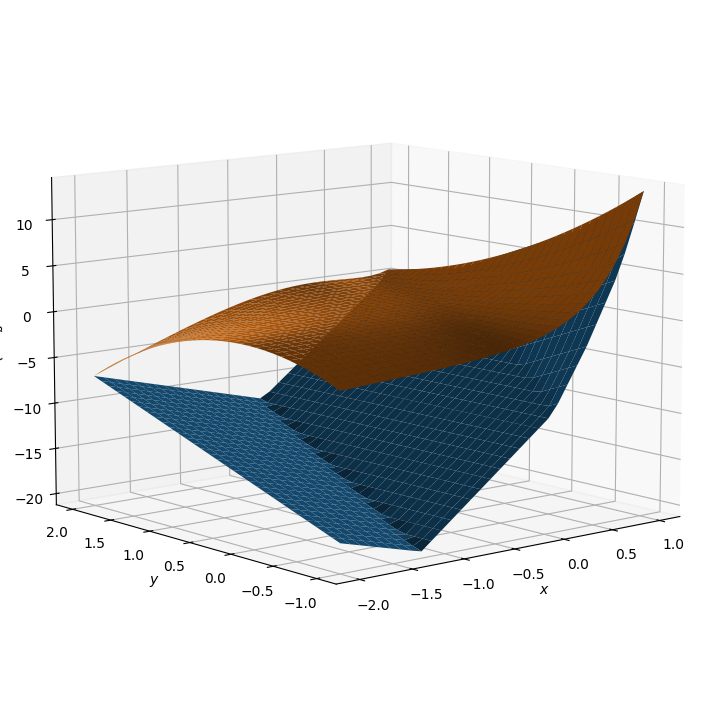

In [12]:
fig = plt.figure(figsize =(14, 9))
ax = plt.axes(projection ='3d')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')

ax.plot_surface(mat_x, mat_y, mat_fl)
ax.plot_surface(mat_x, mat_y, mat_f)
ax.view_init(elev=10, azim=230)

plt.show()